In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
import pandas as pd
df = pd.read_csv("creditcard.csv")

In [3]:
X = df.drop("class",axis=1)
y = df["class"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.naive_bayes import GaussianNB

In [6]:
model = GaussianNB()

In [7]:

model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [8]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.14      0.66      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.83      0.61     56962
weighted avg       1.00      0.99      0.99     56962



In [9]:
y_prob = model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.967730650574805


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [11]:
cm = confusion_matrix(y_test, y_pred)

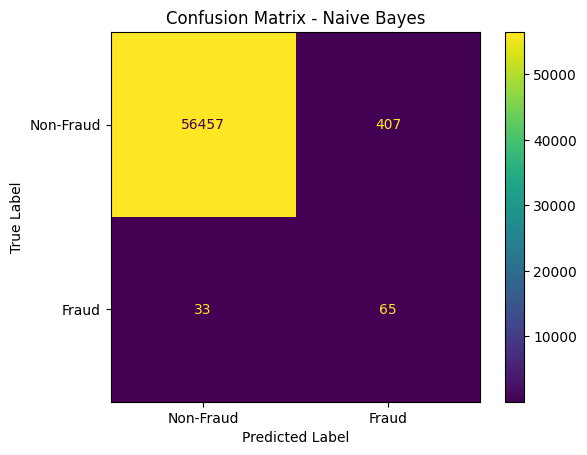

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraud", "Fraud"])
disp.plot(values_format='d')  # shows clean numbers

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [13]:
y_prob=model.predict_proba(X_test)[:,1]

In [14]:
threshhold = 0.9
y_pred_thresh = (y_prob >= threshhold).astype(int)

In [15]:
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.15      0.65      0.24        98

    accuracy                           0.99     56962
   macro avg       0.57      0.82      0.62     56962
weighted avg       1.00      0.99      1.00     56962



In [16]:
import numpy as np
from sklearn.metrics import recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    print(f"Threshold: {t}")
    print("Recall:", recall_score(y_test, y_pred_t))
    print("F1-score:", f1_score(y_test, y_pred_t))
    print("---------------------")

Threshold: 0.1
Recall: 0.6836734693877551
F1-score: 0.21169036334913113
---------------------
Threshold: 0.2
Recall: 0.6836734693877551
F1-score: 0.21967213114754097
---------------------
Threshold: 0.30000000000000004
Recall: 0.6836734693877551
F1-score: 0.22750424448217318
---------------------
Threshold: 0.4
Recall: 0.673469387755102
F1-score: 0.22719449225473323
---------------------
Threshold: 0.5
Recall: 0.6632653061224489
F1-score: 0.22807017543859648
---------------------
Threshold: 0.6
Recall: 0.6632653061224489
F1-score: 0.23172905525846701
---------------------
Threshold: 0.7000000000000001
Recall: 0.6530612244897959
F1-score: 0.23357664233576642
---------------------
Threshold: 0.8
Recall: 0.6530612244897959
F1-score: 0.23703703703703705
---------------------
